# Running your first serverless AIFS forecast on Modal

This notebook shows a serverless approach to run [the Artificial Intelligence Forecasting System (AIFS) model](https://huggingface.co/ecmwf/aifs-single-1.1) on [Modal](https://modal.com), using [Icechunk](https://github.com/earth-mover/icechunk) as storage engine to manage forecast outputs on a [Tigris storage backend](https://www.tigrisdata.com).

```{note}
Before running this notebook, complete the [setup steps](index.md): Modal account and CLI, a Tigris bucket, an Earthmover account with Brightband subscription (for the default `ifs-arraylake` IC source), and the three Modal secrets (`aws-credentials`, `arraylake-api-token`, `huggingface-secret`). Then run `modal run -m aifs_modal._app` once to create the required Modal Volumes.
```

In [ ]:
import datetime as dt
import os
import time

import icechunk
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import zarr

import plot_utils
from aifs_modal import app, run_forecast


def add_valid_time(ds):
    valid_time = ds["init_time"].isel(init_time=0) + ds["lead_time"]
    return ds.assign_coords(valid_time=("lead_time", valid_time.values))

The main parameters to define are the start date, lead time, and initial-conditions source. The default IC source is `ifs-arraylake` (ECMWF IFS data from the Brightband dataset on the Earthmover marketplace — fastest and most reliable). For alternatives including free no-credentials sources, see the [initial conditions notebook](initial-conditions.ipynb).

In [ ]:
# start_date = dt.datetime.fromisoformat("2026-02-16T06:00:00+00:00")
# start_date = OpendataClient().latest().replace(tzinfo=dt.UTC)
# start date for IFS Brightband/Earthmover initial conditions: 1 day ago (safely within
# the rolling window)
start_date = dt.datetime.now(dt.UTC).replace(
    hour=0, minute=0, second=0, microsecond=0
) - dt.timedelta(days=1)
print(f"Start date: {start_date}")
lead_time = 96  # in hours
# n ensemble members
n_members = 10
# Brightband source repo (ECMWF IFS initial conditions on the Earthmover marketplace)
ifs_source_repo = "martibosch/ecmwf-ifs-hres-ics-open"

# storage parameters
storage_bucket = "aifs-modal-unibe"
# deterministic forecast outputs
det_outputs_prefix = "aifs-outputs-det"
det_outputs_branch = "main"
# ensemble forecast outputs
ens_outputs_prefix = "aifs-outputs-ens"
ens_outputs_branch = "main"

Start date: 2026-05-12 00:00:00+00:00


## Deterministic forecast (AIFS-Single)

The [AIFS-Single](https://huggingface.co/ecmwf/aifs-single-1.1) model produces a single deterministic forecast. We run it on Modal and store the outputs in the `aifs-outputs` prefix.

```{note}
`run_forecast` is idempotent: before ingesting ICs or starting inference it checks whether the forecast output already exists on the Modal side, and skips if so. To avoid spinning up the ephemeral app altogether, call `aifs_modal.forecast_exists(date, storage_bucket, ...)` locally first — it reads directly from the output store without touching Modal.
```

In [ ]:
# run a single (deterministic) forecast on modal

# with modal.enable_output():
with app.run():
    _start = time.perf_counter()
    run_forecast.remote(
        start_date,
        storage_bucket,
        ic_source_repo=ifs_source_repo,
        lead_time=lead_time,
        outputs_prefix=det_outputs_prefix,
        outputs_branch=det_outputs_branch,
    )
    print(
        f"Ran {lead_time}-hour deterministic forecast in "
        f"{time.perf_counter() - _start:.1f}s"
    )

Ran 96-hour deterministic forecast in 168.6s


Once the forecast is done, we can read it from the outputs icechunk repository:

In [ ]:
outputs_storage = icechunk.tigris_storage(
    bucket=storage_bucket,
    prefix=det_outputs_prefix,
    region=os.getenv("AWS_REGION", None),
    access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
)
outputs_repo = icechunk.Repository.open(outputs_storage)
# here we just need to read data
outputs_session = outputs_repo.readonly_session(det_outputs_branch)
outputs_root = zarr.open_group(outputs_session.store, mode="r", zarr_format=3)

# dates for which we have forecast outputs stored:
# forecasts = ["00z", "06z", "12z", "18z"]
dates = list(outputs_root.group_keys())
dates.sort(reverse=True)
# read the data into an xarray data set:
date_group = outputs_root[dates[0]]
times = sorted(date_group.group_keys())
forecast_group = f"{dates[0]}/{times[0]}"
det_forecast_ds = xr.open_dataset(
    outputs_session.store,
    group=forecast_group,
    engine="zarr",
    zarr_format=3,
    chunks=None,
)
det_forecast_ds = add_valid_time(det_forecast_ds)
# output the dataset
det_forecast_ds

  2026-05-16T08:13:09.720690Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1776344638779/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.7.2/src/env_config/normalize.rs:121



<xarray.Dataset> Size: 2GB
Dimensions:     (init_time: 1, lead_time: 16, lat: 721, lon: 1440, pressure: 13)
Coordinates:
  * init_time   (init_time) datetime64[ns] 8B 2026-05-12
  * lead_time   (lead_time) timedelta64[us] 128B 0 days 06:00:00 ... 4 days 0...
    valid_time  (lead_time) datetime64[ns] 128B 2026-05-12T06:00:00 ... 2026-...
  * lat         (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon         (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
  * pressure    (pressure) int64 104B 50 100 150 200 250 ... 700 850 925 1000
Data variables: (12/24)
    100u        (init_time, lead_time, lat, lon) float32 66MB ...
    10u         (init_time, lead_time, lat, lon) float32 66MB ...
    10v         (init_time, lead_time, lat, lon) float32 66MB ...
    2t          (init_time, lead_time, lat, lon) float32 66MB ...
    2d          (init_time, lead_time, lat, lon) float32 66MB ...
    cp          (init_time, lead_time, lat, lon) float32 66MB ...
    ...          ...
    swvl1       (init_time, lead_time, lat, lon) float32 66MB ...
    tcc         (init_time, lead_time, lat, lon) float32 66MB ...
    tp          (init_time, lead_time, lat, lon) float32 66MB ...
    swvl2       (init_time, lead_time, lat, lon) float32 66MB ...
    tcw         (init_time, lead_time, lat, lon) float32 66MB ...
    strd        (init_time, lead_time, lat, lon) float32 66MB ...

and now let xarray take it from here, again, running locally **without the need of any GPU**:

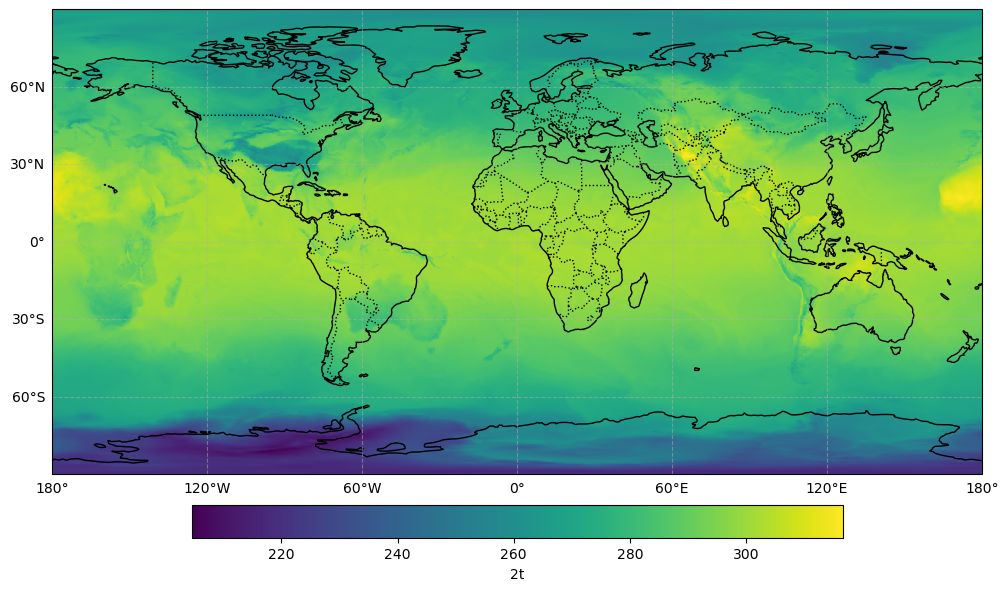

In [ ]:
# plot a given variable
variable = "2t"
_ = plot_utils.make_cartopy_plot(det_forecast_ds[variable].isel(lead_time=0))

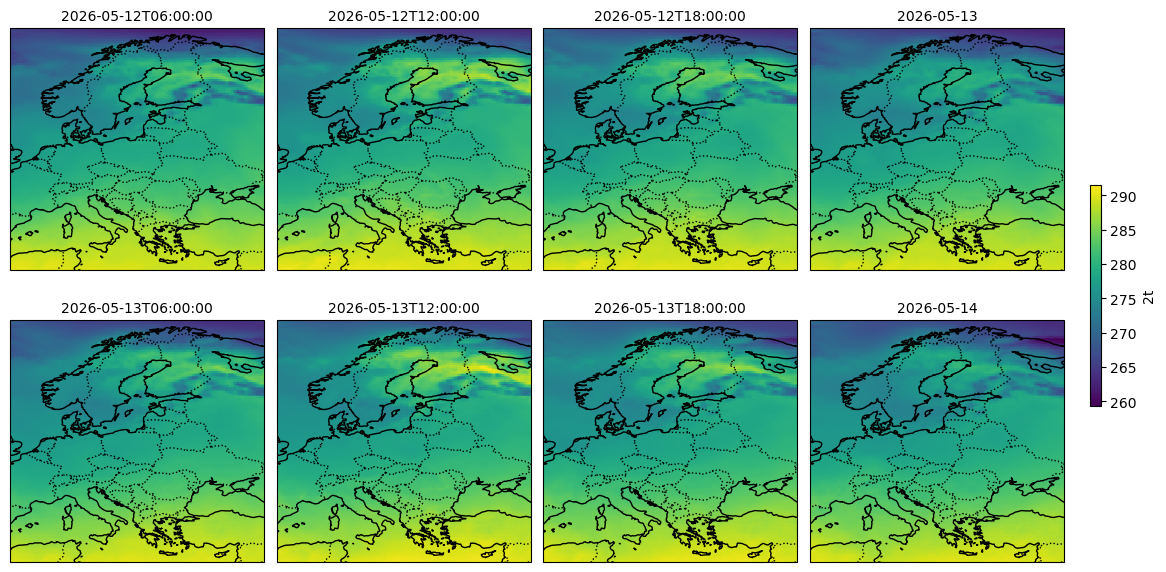

In [ ]:
# plot forecasts for a limited region, e.g., Europe
lat_slice = slice(72, 34)
lon_slice = slice(0, 40)
time_islice = slice(0, 8)
det_plot_da = (
    det_forecast_ds[variable]
    .isel(init_time=0, lead_time=time_islice, drop=True)
    .sel(lat=lat_slice, lon=lon_slice)
    .swap_dims({"lead_time": "valid_time"})
)

g = plot_utils.make_cartopy_facet_plot(
    det_plot_da,
    col="valid_time",
    cbar_kwargs={"shrink": 0.4, "pad": 0.02},
)
g.set_titles("{value}")

## Ensemble forecast (AIFS-ENS)

The [AIFS-ENS](https://huggingface.co/ecmwf/aifs-ens-1.0) model produces probabilistic forecasts: each member applies stochastic perturbations via a different random seed, yielding a distribution of plausible outcomes from the same initial conditions. We run members sequentially on a single GPU and store outputs in the `aifs-outputs-ens` prefix:


In [ ]:
# with modal.enable_output():
with app.run():
    _start = time.perf_counter()
    run_forecast.remote(
        start_date,
        storage_bucket,
        ic_source_repo=ifs_source_repo,
        lead_time=lead_time,
        outputs_prefix=ens_outputs_prefix,
        outputs_branch=ens_outputs_branch,
        n_members=n_members,
    )
    print(
        f"Ran {lead_time}-hour {n_members}-member ensemble forecast in "
        f"{time.perf_counter() - _start:.1f}s"
    )

Ran 96-hour 10-member ensemble forecast in 495.6s


We can now load the ensemble forecast from the outputs storage:


In [ ]:
ens_outputs_storage = icechunk.tigris_storage(
    bucket=storage_bucket,
    prefix=ens_outputs_prefix,
    region=os.getenv("AWS_REGION", None),
    access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
)
ens_outputs_repo = icechunk.Repository.open(ens_outputs_storage)
ens_outputs_session = ens_outputs_repo.readonly_session(ens_outputs_branch)

ens_forecast_group = start_date.strftime("%Y-%m-%d/%Hz")
ens_forecast_ds = xr.open_dataset(
    ens_outputs_session.store,
    group=ens_forecast_group,
    engine="zarr",
    zarr_format=3,
    chunks=None,
)
ens_forecast_ds = add_valid_time(ens_forecast_ds)
ens_forecast_ds

  2026-05-16T08:38:16.201560Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1776344638779/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.7.2/src/env_config/normalize.rs:121



<xarray.Dataset> Size: 15GB
Dimensions:          (ensemble_member: 10, init_time: 1, lead_time: 16,
                      lat: 721, lon: 1440, pressure: 13)
Coordinates:
  * ensemble_member  (ensemble_member) int64 80B 0 1 2 3 4 5 6 7 8 9
  * init_time        (init_time) datetime64[ns] 8B 2026-05-12
  * lead_time        (lead_time) timedelta64[us] 128B 0 days 06:00:00 ... 4 d...
    valid_time       (lead_time) datetime64[ns] 128B 2026-05-12T06:00:00 ... ...
  * lat              (lat) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * lon              (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * pressure         (pressure) int64 104B 50 100 150 200 ... 700 850 925 1000
Data variables: (12/22)
    100u             (ensemble_member, init_time, lead_time, lat, lon) float32 664MB ...
    100v             (ensemble_member, init_time, lead_time, lat, lon) float32 664MB ...
    10v              (ensemble_member, init_time, lead_time, lat, lon) float32 664MB ...
    10u              (ensemble_member, init_time, lead_time, lat, lon) float32 664MB ...
    cp               (ensemble_member, init_time, lead_time, lat, lon) float32 664MB ...
    2t               (ensemble_member, init_time, lead_time, lat, lon) float32 664MB ...
    ...               ...
    sp               (ensemble_member, init_time, lead_time, lat, lon) float32 664MB ...
    ssrd             (ensemble_member, init_time, lead_time, lat, lon) float32 664MB ...
    tp               (ensemble_member, init_time, lead_time, lat, lon) float32 664MB ...
    strd             (ensemble_member, init_time, lead_time, lat, lon) float32 664MB ...
    tcc              (ensemble_member, init_time, lead_time, lat, lon) float32 664MB ...
    tcw              (ensemble_member, init_time, lead_time, lat, lon) float32 664MB ...

Plot the ensemble mean and spread alongside the deterministic forecast for the first valid time (note that ensemble aggregations can take a bit to compute):

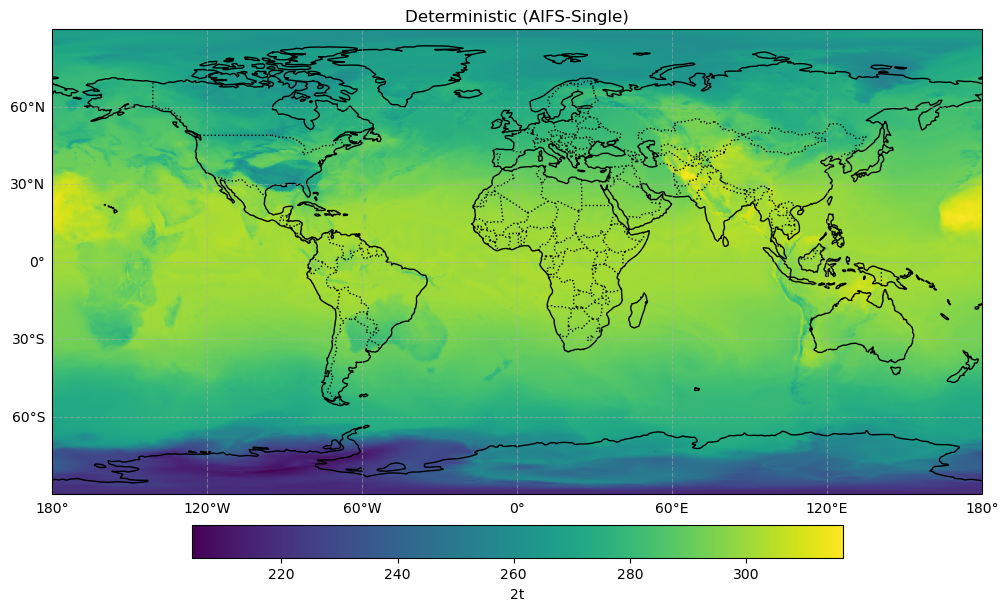

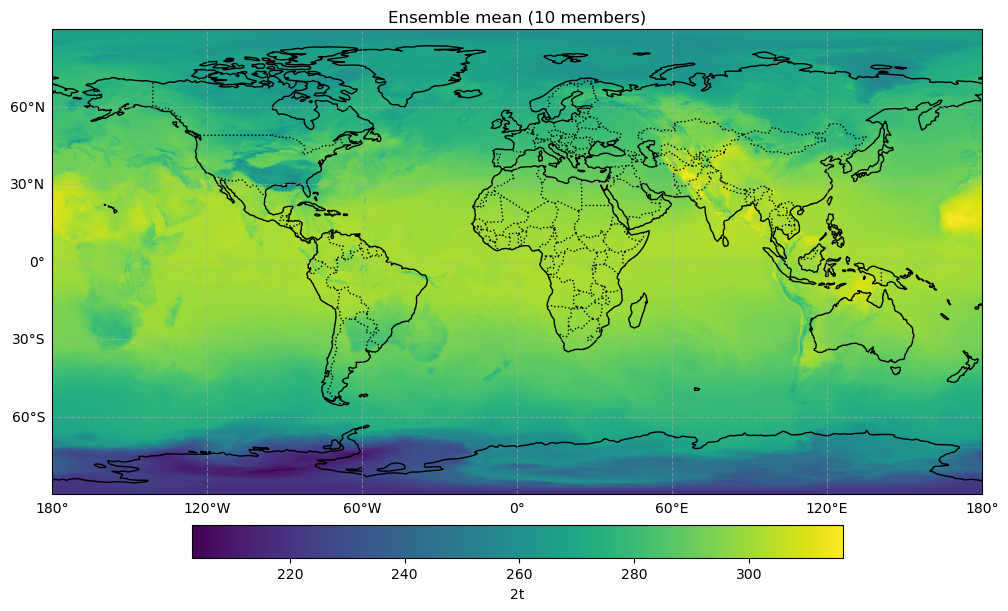

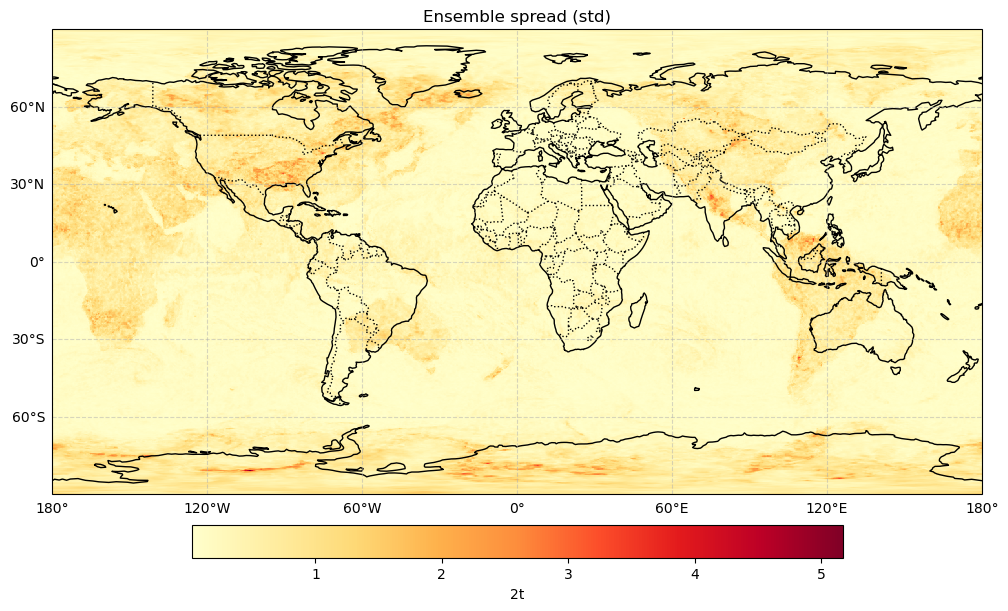

In [ ]:
variable = "2t"
ens_slice = ens_forecast_ds[variable].isel(lead_time=0)
ens_mean = ens_slice.mean(dim="ensemble_member")
ens_std = ens_slice.std(dim="ensemble_member")
det = det_forecast_ds[variable].isel(lead_time=0)

for da, title, cmap in zip(
    [det, ens_mean, ens_std],
    [
        "Deterministic (AIFS-Single)",
        f"Ensemble mean ({n_members} members)",
        "Ensemble spread (std)",
    ],
    ["viridis", "viridis", "YlOrRd"],
):
    _ = plot_utils.make_cartopy_plot(
        da,
        cmap=cmap,
        title=title,
    )

Ensemble 2 m temperature time series at Lausanne (46.52°N, 6.63°E), showing individual members, ensemble mean, and 10th–90th percentile envelope:

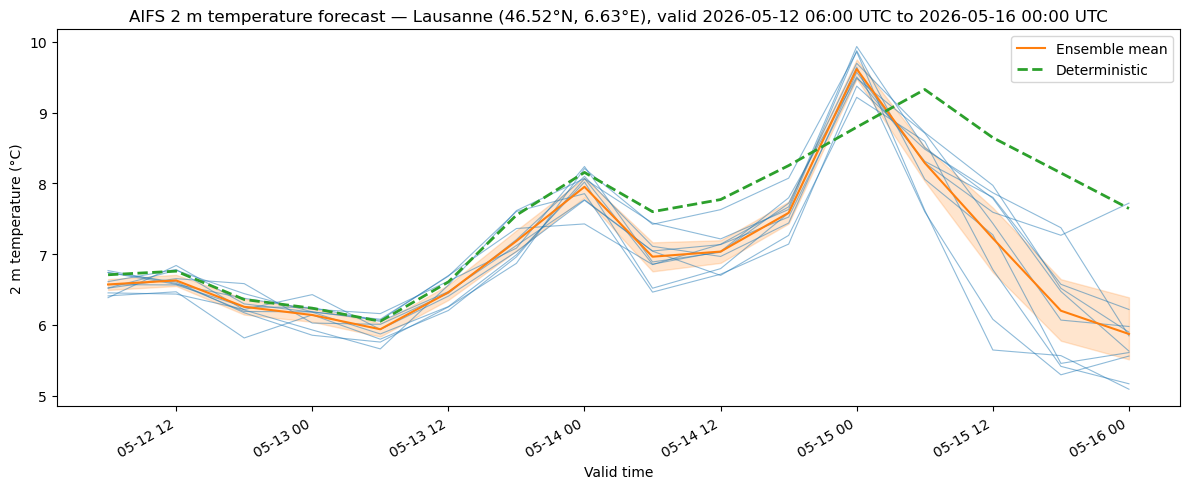

In [ ]:
# Lausanne coordinates
lat, lon = 46.52, 6.63

# extract 2t at nearest grid point for all members, convert to °C
t2m_da = ens_forecast_ds["2t"].sel(lat=lat, lon=lon, method="nearest") - 273.15

# build a long-form dataframe for seaborn
ens_df = t2m_da.to_dataframe(name="2t").reset_index().assign(source="AIFS-ENS member")

# deterministic forecast
det_da = det_forecast_ds["2t"].sel(lat=lat, lon=lon, method="nearest") - 273.15
det_df = (
    det_da.to_dataframe(name="2t")
    .reset_index()
    .assign(source="AIFS-Single", ensemble_member=-1)
)

# plot_df = pd.concat([ens_df, det_df], ignore_index=True)
# make a wider plot
fig, ax = plt.subplots(figsize=(12, 5))
# default seaborn colors
colors = sns.color_palette()
# plot ensembles without any estimator (thinner lines)
sns.lineplot(
    data=ens_df,
    x="valid_time",
    y="2t",
    units="ensemble_member",
    estimator=None,
    color=colors[0],
    alpha=0.5,
    linewidth=0.8,
    ax=ax,
)
# plot ensembles mean and CI
sns.lineplot(
    data=ens_df,
    x="valid_time",
    y="2t",
    color=colors[1],
    label="Ensemble mean",
    ax=ax,
)
# plot deterministic (dashed thicker line)
sns.lineplot(
    data=det_df,
    x="valid_time",
    y="2t",
    color=colors[2],
    linewidth=2,
    linestyle="--",
    label="Deterministic",
    ax=ax,
)

ax.set_ylabel("2 m temperature (°C)")
ax.set_xlabel("Valid time")
valid_start = det_df["valid_time"].min().strftime("%Y-%m-%d %H:%M UTC")
valid_end = det_df["valid_time"].max().strftime("%Y-%m-%d %H:%M UTC")
ax.set_title(
    f"AIFS 2 m temperature forecast — Lausanne ({lat}°N, {lon}°E), "
    f"valid {valid_start} to {valid_end}"
)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()

## Cleanup

Remove initial conditions and forecast outputs from the bucket.

In [ ]:
import storage_utils

storage_utils.delete_prefixes(
    storage_bucket,
    det_outputs_prefix,
    ens_outputs_prefix,
)

deleted 1552 object(s) under s3://aifs-modal-unibe/aifs-outputs-det
deleted 365 object(s) under s3://aifs-modal-unibe/aifs-outputs-ens
done — removed 1917 objects from s3://aifs-modal-unibe/
